# 03_Metadata_explore

Looking at the metadata.

Notes
- They save the annotations in a way that was annoying to parse
- Seems like the cell type annotations do not have a fixed convention?
- See that the "none" condition is completely missing the T cell/NK cell subset

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
from pathlib import Path

In [2]:
%matplotlib inline

In [3]:
outdir = Path("results/04")
outdir.mkdir(parents=True, exist_ok=True)

In [4]:
h5ad_path = "/home/unix/cchu/projects/ZmanR/pqe/results/01/py_version/cells_markers.h5ad"
adata = sc.read_h5ad(h5ad_path)

In [5]:
adata.obs['Treatment'].value_counts(dropna=False)

Treatment
IgG       13440
aTrem2     8448
Name: count, dtype: int64

In [6]:
import pandas as pd                                                                                                                                                             
import io      
import re                                                                                                                                                                 
                
def preprocess_metadata(path):                                                                                                                                                  
    mouse_pat = re.compile(r'(Mouse[\s_]\d+)')
    time_pat  = re.compile(r'\b(\d+H|Negative|Not_Assigned)\b')                                                                                                                 

    with open(path) as f:                                                                                                                                                       
        lines = f.readlines()
                                                                                                                                                                                
    header = lines[0].split()
    rows = []                                                                                                                                                                   
    for line in lines[1:]:                                                                                                                                                      
        raw = line.strip()
                                                                                                                                                                                
        mouse_m = mouse_pat.search(raw)                                                                                                                                         
        time_m  = time_pat.search(raw)
        mouse   = mouse_m.group(1).replace(" ", "_") if mouse_m else None                                                                                                       
        time_as = time_m.group(1) if time_m else None                                                                                                                           
                                                                                                                                                                                
        # everything before the mouse match is the fixed left block                                                                                                             
        left_str = raw[:mouse_m.start()].strip() if mouse_m else ""                                                                                                             
        left = left_str.split()   # index + Well_ID ... Cell_barcode (10 fields)                                                                                                
                                                                                                                                                                                
        # everything after time_assignment is cluster_colors + sc_x sc_y Treatment                                                                                              
        after_time = raw[time_m.end():].strip() if time_m else ""                                                                                                               
        right = after_time.split()  # sc_x, sc_y, Treatment are last 3                                                                                                          
        cluster = " ".join(right[:-3]) if len(right) > 3 else right[0] if right else None                                                                                       
        sc_x, sc_y, treatment = (right[-3], right[-2], right[-1]) if len(right) >= 3 else (None, None, None)                                                                    
                                                                                                                                                                                
        rows.append(left + [mouse, time_as, cluster, sc_x, sc_y, treatment])                                                                                                    
                                                                                                                                                                                
    cols = ["row_index"] + header                                                                                                                                               
    df = pd.DataFrame(rows, columns=cols).set_index("row_index")
    df["sc_x"] = pd.to_numeric(df["sc_x"], errors="coerce")                                                                                                                     
    df["sc_y"] = pd.to_numeric(df["sc_y"], errors="coerce")                                                                                                                     
    return df                                                                                                                                                               
                                                                                                                                                                            

In [7]:
metadata_df = preprocess_metadata("/mnt/thechenlab/ClaudiaC/zmanseq/metadata.txt") 

In [8]:
metadata_df.query("Amp_batch_ID == 'AB5234'")

,Well_ID,well_coordinates,Amp_batch_ID,Subject_ID,Number_of_cells,Seq_batch_ID,Pool_barcode,Pool_barcode_i5,Cell_barcode,Mouse,time_assignment,cluster_colors,sc_x,sc_y,Treatment
row_index,,,,,,,,,,,,,,,
1,W2035161,A1,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,CTATTCG,Mouse_3,Negative,TAM,311.057269,124.155339,None
2,W2035162,A2,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,TGATCCG,Mouse_3,Negative,TAM,352.239330,108.970629,None
3,W2035163,A3,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,GTATGCG,Mouse_3,18H,Not_annotated,NaN,NaN,None
4,W2035164,A4,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,TGACGTC,Mouse_3,Negative,TAM,344.319641,37.737412,None
5,W2035165,A5,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,TGTCACG,Mouse_3,Negative,Monocytes inflammatory,120.703492,245.883531,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,W2035540,P20,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,CTACCGA,Mouse_3,Negative,Not_annotated,NaN,NaN,None
381,W2035541,P21,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,CAATGCG,Mouse_3,Negative,TAM,501.502783,277.049216,None
382,W2035542,P22,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,TCGTAGC,Mouse_3,Negative,TAM,371.408687,130.224967,None


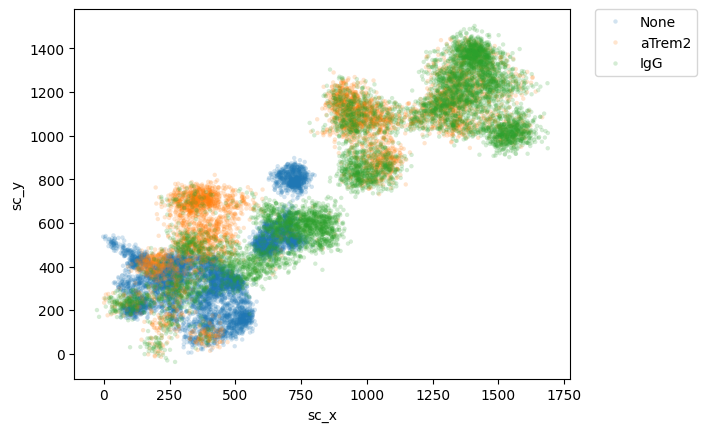

In [9]:
sns.scatterplot(data=metadata_df[~metadata_df['time_assignment'].isin(['Negative', 'Not_Assigned'])], x="sc_x", y="sc_y", hue="Treatment", s=10, linewidth=0, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
plt.show()

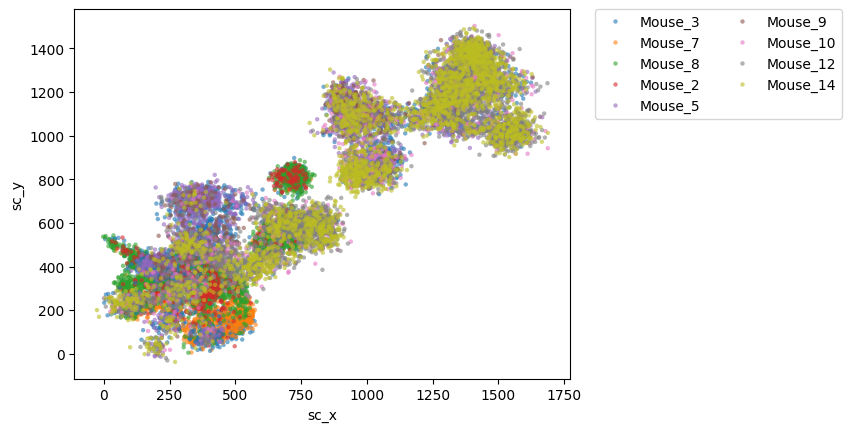

In [10]:
sns.scatterplot(data=metadata_df[~metadata_df['time_assignment'].isin(['Negative', 'Not_Assigned'])], x="sc_x", y="sc_y", hue="Mouse", s=10, linewidth=0, alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

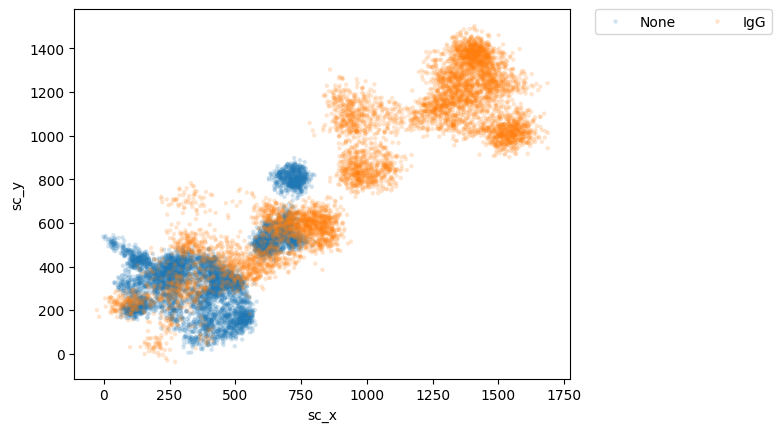

In [11]:
sns.scatterplot(data=metadata_df[
    ~metadata_df['time_assignment'].isin(['Negative', 'Not_Assigned']) &
    (metadata_df['Treatment'] != "aTrem2")
], x="sc_x", y="sc_y", hue="Treatment", s=10, linewidth=0, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

Some kind of IgG/aTrem effect that recruits T cells and NK cells?

/tmp/ipykernel_2735467/1320306756.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis_r")


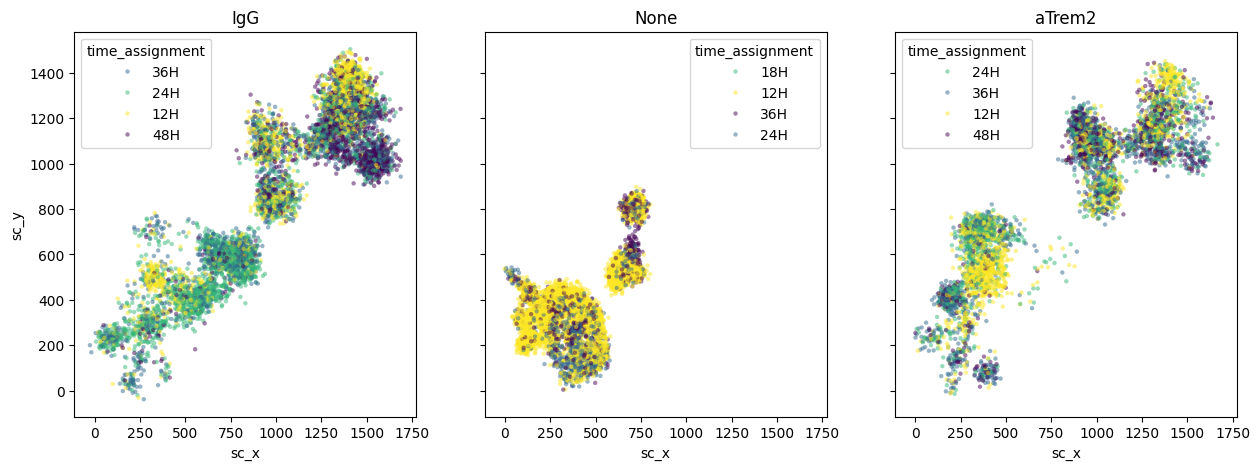

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
cmap = plt.cm.get_cmap("viridis_r")

for i, (treatment, df) in enumerate(metadata_df[~metadata_df['time_assignment'].isin(['Not_Assigned', 'Negative'])].groupby("Treatment")):

    label_order = df['time_assignment'].sort_values().unique()
    norm = plt.Normalize(vmin=0, vmax=len(label_order) - 1)
    time_colors = {label: cmap(norm(i)) for i, label in enumerate(label_order)}

    sns.scatterplot(data=df[
        ~df['time_assignment'].isin(['Negative', 'Not_Assigned']) 
    ], x="sc_x", y="sc_y", hue="time_assignment", s=10, linewidth=0, alpha=0.5, ax=axs[i], palette=time_colors, legend=True)
    axs[i].set_title(treatment)
    # # colormap
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    # cbar = axs[i].figure.colorbar(sm, ax=axs[i], orientation="horizontal", pad=0.2)
    # cbar.ax.set_xticks(np.arange(len(label_order)))
    # cbar.ax.set_xticklabels(label_order)

plt.show()

/tmp/ipykernel_1140854/4090463551.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis_r")


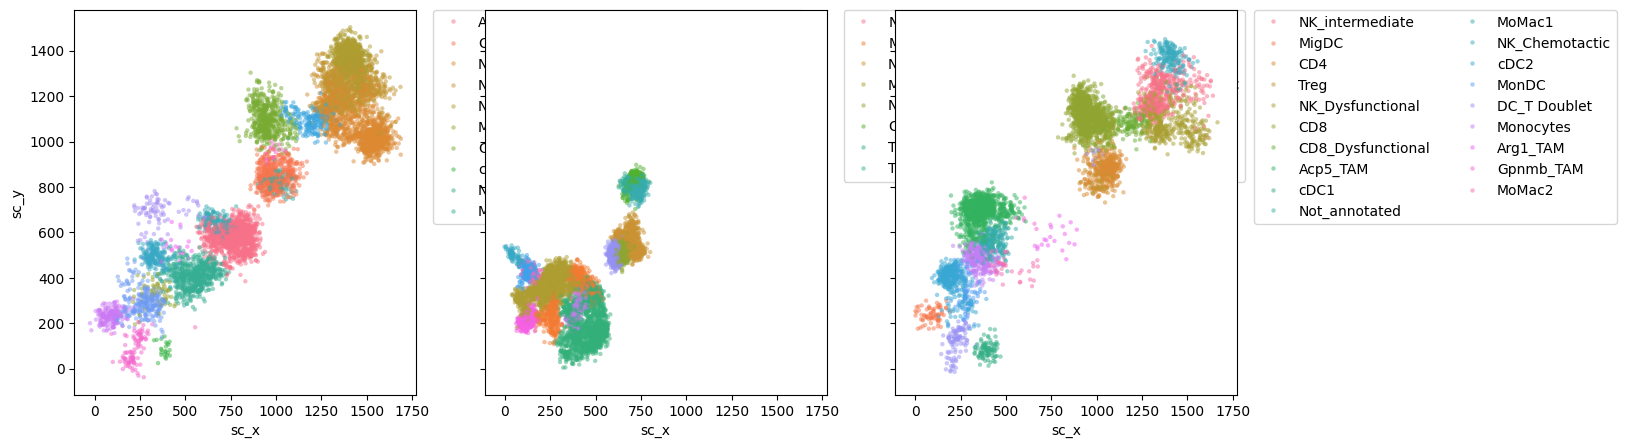

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
cmap = plt.cm.get_cmap("viridis_r")

for i, (treatment, df) in enumerate(metadata_df[~metadata_df['time_assignment'].isin(['Not_Assigned', 'Negative'])].groupby("Treatment")):

    sns.scatterplot(data=df[
        ~df['time_assignment'].isin(['Negative', 'Not_Assigned']) 
    ], x="sc_x", y="sc_y", hue="cluster_colors", s=10, linewidth=0, alpha=0.5, ax=axs[i])

    axs[i].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
    

plt.show()

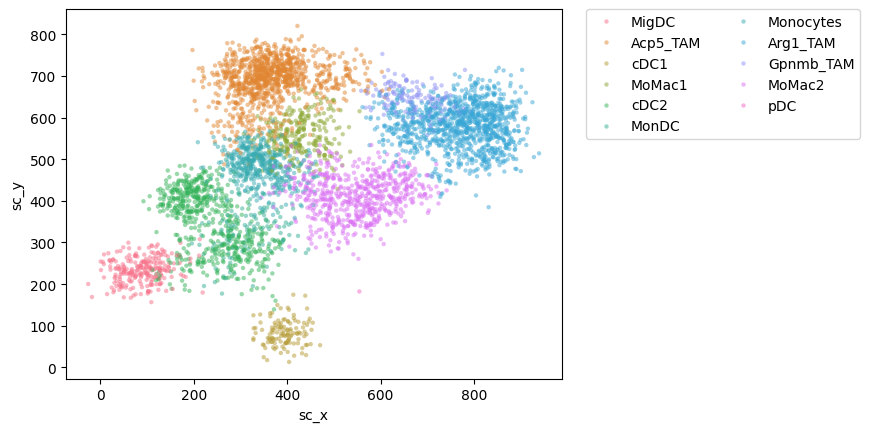

In [21]:
sns.scatterplot(data=metadata_df[
    ~metadata_df['time_assignment'].isin(['Negative', 'Not_Assigned']) &
    (metadata_df['cluster_colors'].isin(["Monocyte", "MoMac1", "Monocytes", "Gpnmb_TAM", "Arg1_TAM", "MigDC", "Acp5_TAM", "cDC1", "cDC2", "MoMac2", "MoMac", "pDC", "MonDC"])) & 
    (metadata_df['Treatment'] != "None")
], x="sc_x", y="sc_y", hue="cluster_colors", s=10, linewidth=0, alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

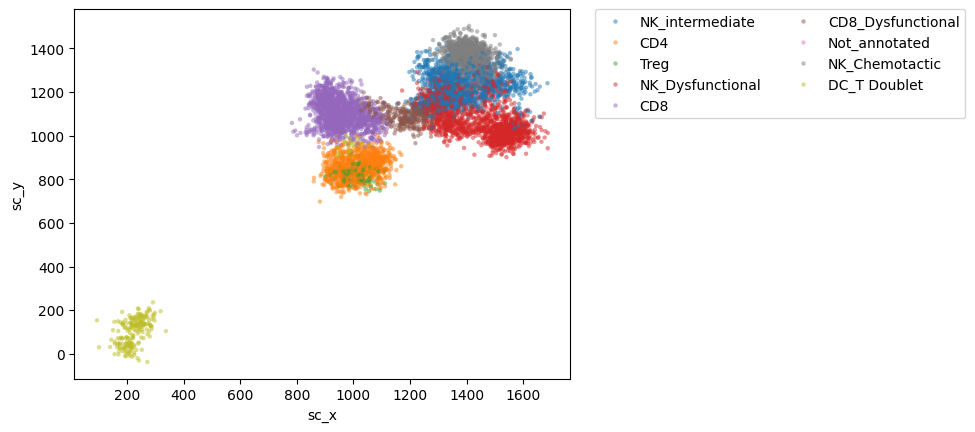

In [22]:
sns.scatterplot(data=metadata_df[
    ~metadata_df['time_assignment'].isin(['Negative', 'Not_Assigned']) &
    ~(metadata_df['cluster_colors'].isin(["Monocyte", "MoMac1", "Monocytes", "Gpnmb_TAM", "Arg1_TAM", "MigDC", "Acp5_TAM", "cDC1", "cDC2", "MoMac2", "MoMac", "pDC", "MonDC"])) & 
    (metadata_df['Treatment'] != "None")
], x="sc_x", y="sc_y", hue="cluster_colors", s=10, linewidth=0, alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

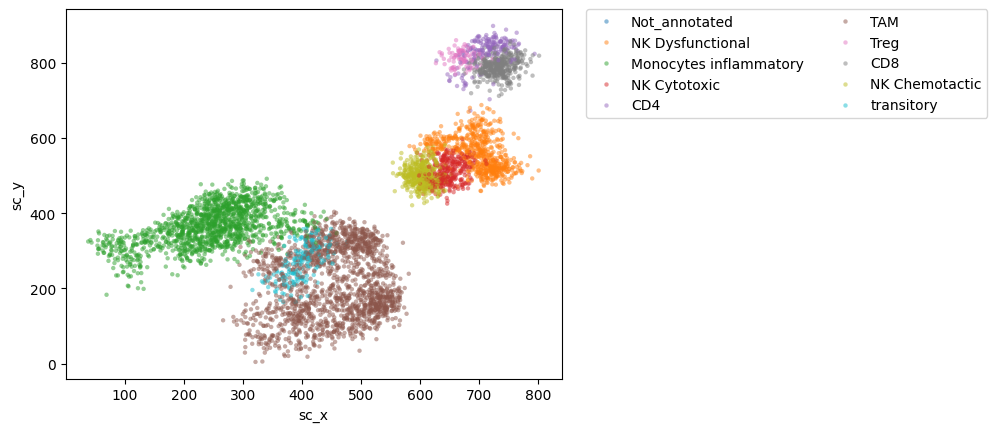

In [23]:
sns.scatterplot(data=metadata_df[
    ~metadata_df['time_assignment'].isin(['Negative', 'Not_Assigned']) &
    ~(metadata_df['cluster_colors'].isin(["Monocyte", "MoMac1", "Monocytes", "Gpnmb_TAM", "Arg1_TAM", "MigDC", "Acp5_TAM", "cDC1", "cDC2", "MoMac2", "MoMac", "pDC", "MonDC"])) & 
    (metadata_df['Treatment'] == "None")
], x="sc_x", y="sc_y", hue="cluster_colors", s=10, linewidth=0, alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)
plt.show()

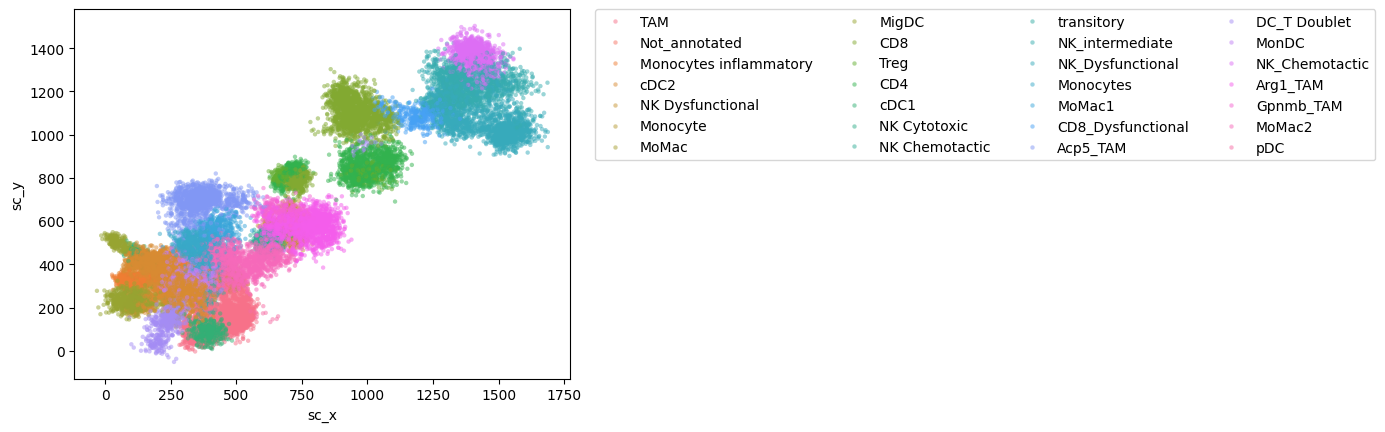

In [24]:
sns.scatterplot(data=metadata_df.dropna(subset=["cluster_colors"]), x="sc_x", y="sc_y", hue="cluster_colors", s=10, linewidth=0, alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=4)
plt.show()

# Colon and Lung data

In [109]:
def preprocess_metadata_q27(path):                                                                                                                                              
    with open(path) as f:                                                                                                                                                       
        lines = f.readlines()                                                                                                                                                   
                                                                                                                                                                                
    header = lines[0].split()                                                                                                                                                   
    # 22 cols total; data rows have 23-24 fields due to spaces in Organ                                                                                                         
    # first 14 fields: Well_ID ... Gating (fixed, no spaces)                                                                                                                    
    # last 7 fields: Mouse, sc_x, sc_y, mc, celltype, time_group, Stain (fixed)                                                                                                 
    # middle = Organ (1-3 words: "APC Blood", "time stamp Blood", etc.)                                                                                                         
    n_left = 14                                                                                                                                                                 
    n_right = 7                                                                                                                                                                 
                                                                                                                                                                                
    rows = []                                                                                                                                                                   
    for line in lines[1:]:                                                                                                                                                      
        parts = line.strip().split()                                                                                                                                            
        left = parts[:n_left]                                                                                                                                                   
        right = parts[-n_right:]                                                                                                                                                
        organ = " ".join(parts[n_left:-n_right])                                                                                                                                
        rows.append(left + [organ] + right)                                                                                                                                     
                                                                                                                                                                                
    df = pd.DataFrame(rows, columns=header)                                                                                                                                     
                                                                                                                                                                                
    # fix dtypes                                                                                                                                                                
    for col in ["sc_x", "sc_y", "mc", "Spike_dilution", "Spike_volume_ul",                                                                                                    
                "Number_of_cells", "is_primer_added", "Raw_RNA_amount"]:                                                                                                        
        df[col] = pd.to_numeric(df[col], errors="coerce")                                                                                                                       
                                                                                                                                                                                
    return df                                                                                                                                                                   
                                                                                                                                                                                  
meta_q27_df = preprocess_metadata_q27("/mnt/thechenlab/ClaudiaC/zmanseq/metadata_q27.txt")    